In [1]:
import icechunk
import matplotlib.pyplot as plt
import s3fs
import xarray as xr

In [2]:
SOURCE_COOP_ROOT = "s3://us-west-2.opendata.source.coop/carbonplan/srm-downscaling"
STORE_URI = f"{SOURCE_COOP_ROOT}/output/production/CESM2-WACCM6-ERA5-global.icechunk"
BRANCH = "v1.0.0"
RAW_GCM_STORE_URI = f"{SOURCE_COOP_ROOT}/input/processed/CESM2-WACCM6.icechunk"
METHOD = "bcsd"
SCENARIO_GROUP = "g6_1p5k"
VARIABLE = "tasmax"
ENSEMBLE_MEMBER = "003"
SAMPLE_DAY = "2070-01-01"

REGIONS = {
    "south-africa": {"label": "South Africa", "lat": (-35, -22), "lon": (16, 33)},
    "india": {"label": "India", "lat": (7.5, 37.5), "lon": (68, 97)},
    "bolivia": {"label": "Bolivia", "lat": (-23, -9), "lon": (-70, -57)},
    "western-us": {"label": "Western US", "lat": (31, 49), "lon": (-125, -102)},
    "philippines": {"label": "Philippines", "lat": (5, 21), "lon": (116, 127)},
}

In [3]:
def open_source_coop_group(path, group, branch=BRANCH):
    bucket, prefix = path.replace("s3://", "").split("/", 1)
    storage = icechunk.s3_storage(
        bucket=bucket,
        prefix=prefix,
        anonymous=True,
        region="us-west-2",
    )
    repo = icechunk.Repository.open(storage)
    session = repo.readonly_session(branch=branch)
    return xr.open_zarr(
        session.store,
        group=group,
        consolidated=False,
        zarr_format=3,
        chunks={},
    )


def subset_bbox(obj, lat, lon):
    """Subset a Dataset or DataArray using either longitude convention."""
    lat_min, lat_max = lat
    lon_min, lon_max = lon

    lat_ascending = float(obj.lat[0]) < float(obj.lat[-1])
    lat_slice = slice(lat_min, lat_max) if lat_ascending else slice(lat_max, lat_min)

    uses_360 = float(obj.lon.min()) >= 0 and float(obj.lon.max()) > 180
    if uses_360:
        lon_min, lon_max = (lon_min % 360, lon_max % 360)

    lon_ascending = float(obj.lon[0]) < float(obj.lon[-1])
    lon_slice = slice(lon_min, lon_max) if lon_ascending else slice(lon_max, lon_min)
    return obj.sel(lat=lat_slice, lon=lon_slice)

In [4]:
fine_group = f"{METHOD}/{SCENARIO_GROUP}/{VARIABLE}/{ENSEMBLE_MEMBER}"

downscaled_source = open_source_coop_group(STORE_URI, fine_group)
coarse_source = open_source_coop_group(RAW_GCM_STORE_URI, SCENARIO_GROUP, branch="main").sel(
    ensemble_member=ENSEMBLE_MEMBER
)

In [5]:
coarse_global = coarse_source[VARIABLE].sel(time=SAMPLE_DAY).load()
downscaled_global = downscaled_source[VARIABLE].sel(time=SAMPLE_DAY).load()

coarse = {}
downscaled = {}

for slug, region in REGIONS.items():
    bounds = {"lat": region["lat"], "lon": region["lon"]}
    coarse[slug] = subset_bbox(coarse_global, **bounds)
    downscaled[slug] = subset_bbox(downscaled_global, **bounds)

Text(0.5, 0.98, 'tasmax on 2070-01-01 — CESM2-WACCM G6-1.5K (v1.0.0)')

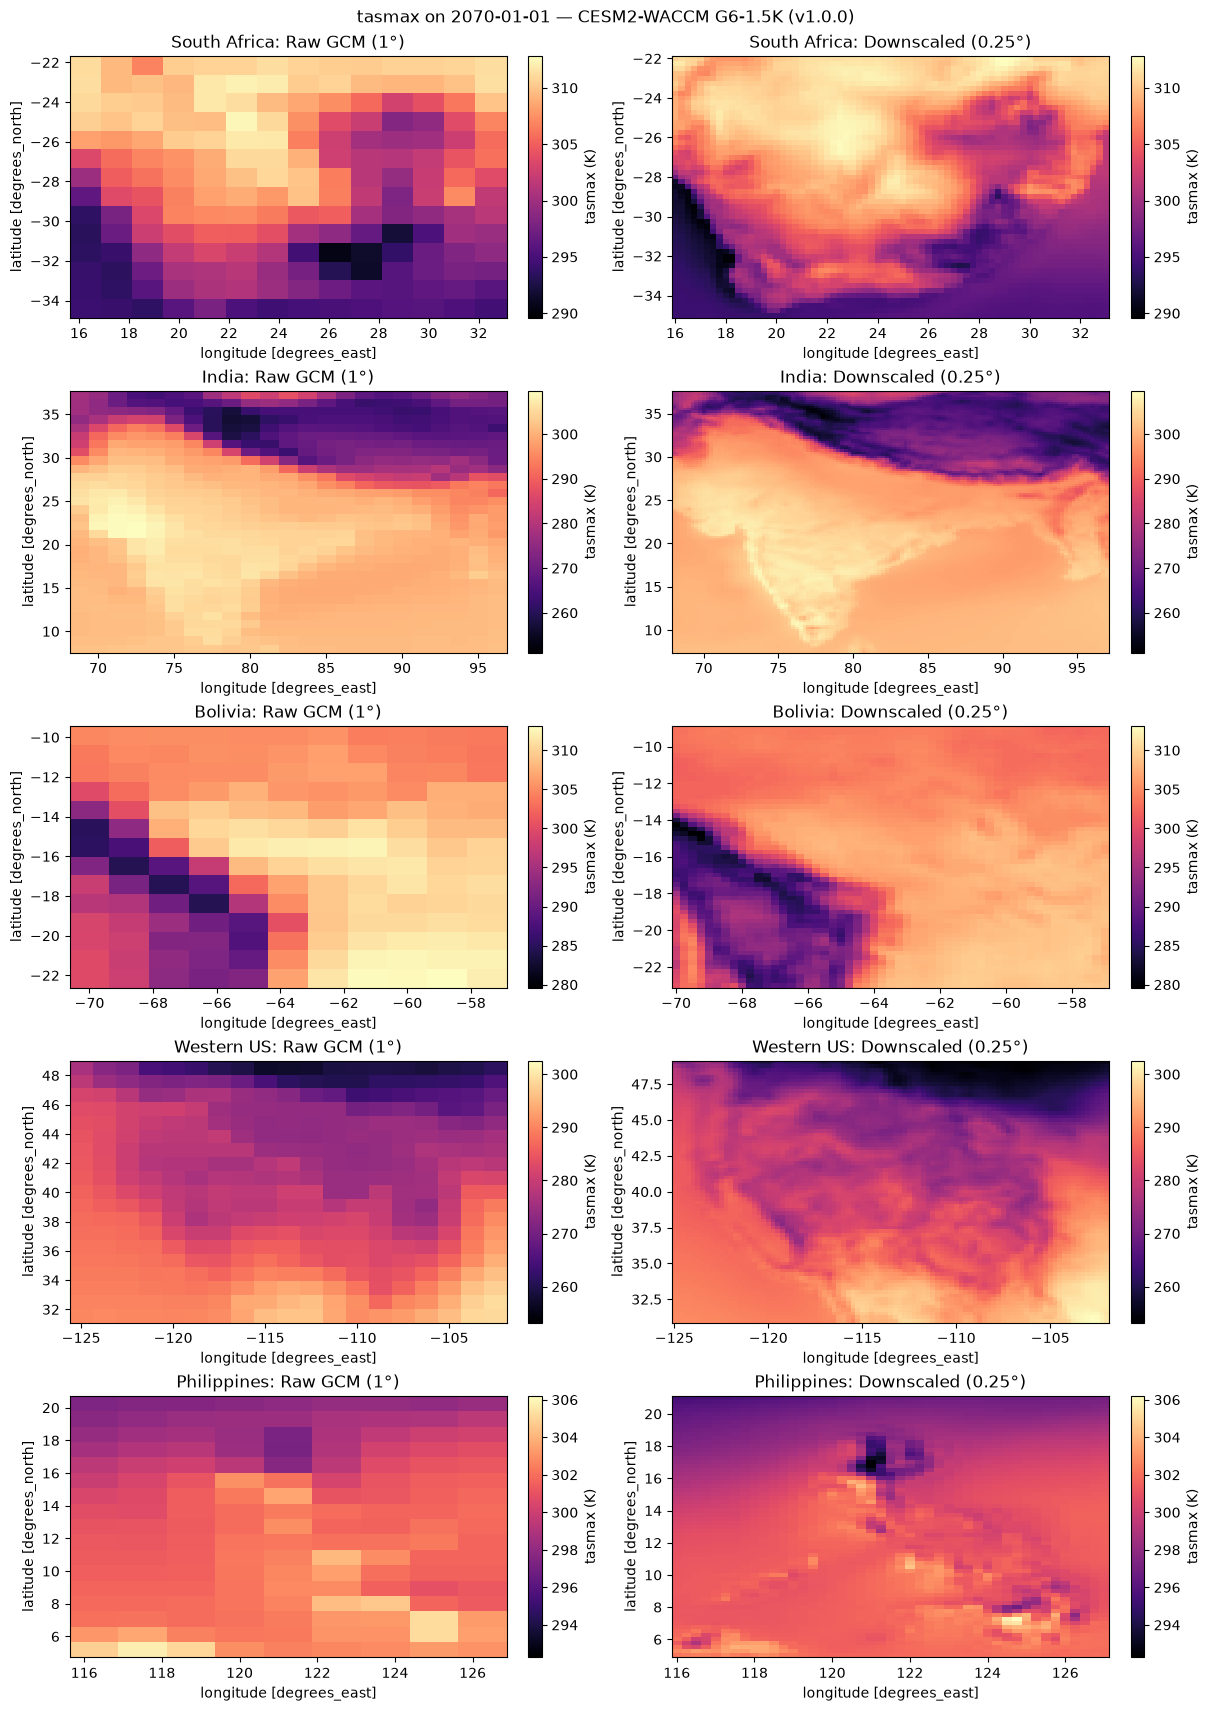

In [6]:
fig, axes = plt.subplots(
    nrows=len(REGIONS),
    ncols=2,
    figsize=(12, 3.4 * len(REGIONS)),
    constrained_layout=True,
)

for row, (slug, region) in enumerate(REGIONS.items()):
    vmin = min(float(coarse[slug].min()), float(downscaled[slug].min()))
    vmax = max(float(coarse[slug].max()), float(downscaled[slug].max()))
    for column, (title, data) in enumerate(
        [("Raw GCM (1°)", coarse[slug]), ("Downscaled (0.25°)", downscaled[slug])]
    ):
        data.plot(
            ax=axes[row, column],
            vmin=vmin,
            vmax=vmax,
            cmap="magma",
            cbar_kwargs={"label": f"{VARIABLE} ({data.attrs.get('units', 'K')})"},
        )
        axes[row, column].set_title(f"{region['label']}: {title}")

fig.suptitle(f"{VARIABLE} on {SAMPLE_DAY} — CESM2-WACCM G6-1.5K ({BRANCH})")

In [7]:
OUTPUT_ROOT = "s3://carbonplan-srm/output/explainer/figures"
OUTPUT_PATHS = {
    "coarse": f"{OUTPUT_ROOT}/figure1_coarse.zarr",
    "downscaled": f"{OUTPUT_ROOT}/figure1_downscaled.zarr",
}
OUTPUT_CHUNKS = {"coarse": (64, 64), "downscaled": (128, 128)}


def prepare_output(data, source_metadata):
    ds = data.to_dataset(name=VARIABLE).drop_encoding()
    ds.attrs.update(
        {
            "sample_day": SAMPLE_DAY,
            "spatial_extent": "global",
            **source_metadata,
        }
    )
    return ds

In [8]:
outputs = {
    "coarse": (
        coarse_global,
        {
            "source_store": RAW_GCM_STORE_URI,
            "source_group": SCENARIO_GROUP,
            "source_kind": "raw GCM",
        },
    ),
    "downscaled": (
        downscaled_global,
        {
            "source_store": STORE_URI,
            "source_branch": BRANCH,
            "source_group": fine_group,
            "source_kind": f"{METHOD.upper()} downscaled",
        },
    ),
}

public_s3 = s3fs.S3FileSystem(s3_additional_kwargs={"ACL": "public-read"})

for resolution, (data, source_metadata) in outputs.items():
    output_path = OUTPUT_PATHS[resolution]
    prepare_output(data, source_metadata).to_zarr(
        public_s3.get_mapper(output_path),
        mode="w",
        encoding={VARIABLE: {"chunks": OUTPUT_CHUNKS[resolution]}},
    )

/Users/shaneloeffler/dev/carbonplan/srm-downscaling/.venv/lib/python3.13/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=3, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)


/Users/shaneloeffler/dev/carbonplan/srm-downscaling/.venv/lib/python3.13/site-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


/Users/shaneloeffler/dev/carbonplan/srm-downscaling/.venv/lib/python3.13/site-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
